(20, 11)
Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0 

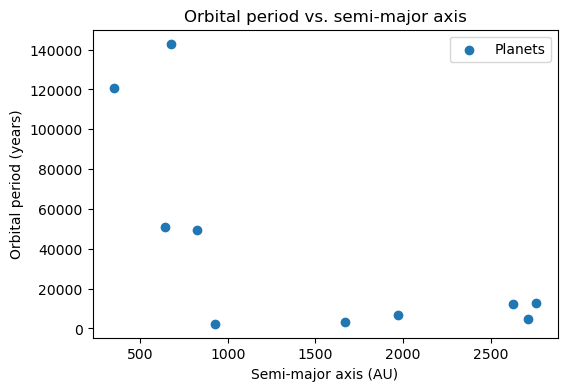

Fit: T = 0.14 * a^(3/2)


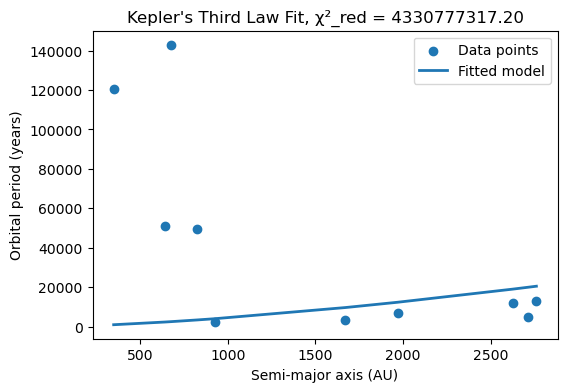

In [22]:
# File: kepler.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv(r"C:\Users\danie\python_decal_fall25\course_assignments\homework9\solar_system.csv")

# 3.0.4: 

print(df.shape) # 20 Rows, 11 Columns
print(df.columns)
print(df.head())
print(df.tail())
print(df["Attribute"])

# 3.0.5

row_Orbital_Period = 1
row_Perihelion = 2
row_Aphelion = 3

orbital_period = df.iloc[row_Orbital_Period, 1:].astype(float).values
perihelion = df.iloc[row_Perihelion, 1:].astype(float).values
aphelion = df.iloc[row_Aphelion, 1:].astype(float).values

print(orbital_period)
print(perihelion)
print(aphelion)

# 3.0.6: Define perihelion, aphelion and semi-major axis in your own words.

# Perihelion: the point in the orbit where the object is closest to the Sun.
# Aphelion: the point in the orbit where the object is farthest from the Sun.
# Semi-major axis: half the longest diameter of the elliptical orbit

# 3.0.7: Compute Semi-Major Axis

semi_major_axis = (perihelion + aphelion) / 2.0
print("Semi-major axis:", semi_major_axis)

# 3.0.8: Add the semi-major axis as a new row to your DataFrame. Don’t forget units

row_name = "Semi-major axis (AU)"
semi_series = pd.Series([row_name] + semi_major_axis.tolist(), index=df.columns)
df = pd.concat([df, semi_series.to_frame().T], ignore_index=True)

# 3.0.9: Print the new shape of your DataFrame. How many rows? How many columns?

print(df.shape)
print(df.tail())

# 3.0.10: Plot the semi major axis vs. orbital period using plt.scatter().

plt.figure(figsize=(6, 4))
plt.scatter(semi_major_axis, orbital_period)

plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital period (years)")
plt.title("Orbital period vs. semi-major axis")
plt.legend(["Planets"])
plt.show()

# 3.0.11:

def keplers_third_law(a, m):
    return m * a ** 1.5

# 3.0.12:

p0 = [1.0]
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)
m_fit = popt[0]

# 3.0.14:

print(f"Fit: T = {m_fit:.2f} * a^(3/2)")

# 3.0.15: 

T_model = keplers_third_law(semi_major_axis, m_fit)
residuals = orbital_period - T_model

chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof

# 3.0.16:
sorted_indices = np.argsort(semi_major_axis)
a_sorted = semi_major_axis[sorted_indices]
T_sorted_model = keplers_third_law(a_sorted, m_fit)

plt.figure(figsize=(6, 4))
plt.scatter(semi_major_axis, orbital_period, label="Data points")
plt.plot(a_sorted, T_sorted_model, label="Fitted model", linewidth=2)

plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital period (years)")
plt.title(f"Kepler's Third Law Fit, χ²_red = {chi2_reduced:.2f}")
plt.legend()
plt.show()

df.to_csv("kepler.csv", index=False)